In [11]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import pearsonr, spearmanr

# accuracy

In [12]:
with open('../8.Accuracy/data.json', 'r', encoding='utf-8') as file:
    data = json.load(file)

accuracy_data = {}
satisfaction_data = {}
has_code_location = {}
for nfr in data:
    nfr_id = nfr['id']
    llm_response = nfr['llm_response']
    gt_label = nfr['satisfaction_level'].lower()
    if gt_label == 'satisfied':
        gt = 4
    elif gt_label == 'weakly satisfied':
        gt = 3
    elif gt_label == 'weakly denied':
        gt = 2
    elif gt_label == 'denied':
        gt = 1
    else:
        raise Exception(nfr_id)
    accuracy_data[nfr_id] = 1 - abs(gt - llm_response) / 3
    satisfaction_data[nfr_id] = nfr['satisfaction_level']
    locs = nfr.get('code_location') or []
    has_code_location[nfr_id] = len(locs) > 0

Counter({1.0: 67, 0.6666666666666667: 55, 0.33333333333333337: 22, 0.0: 4})


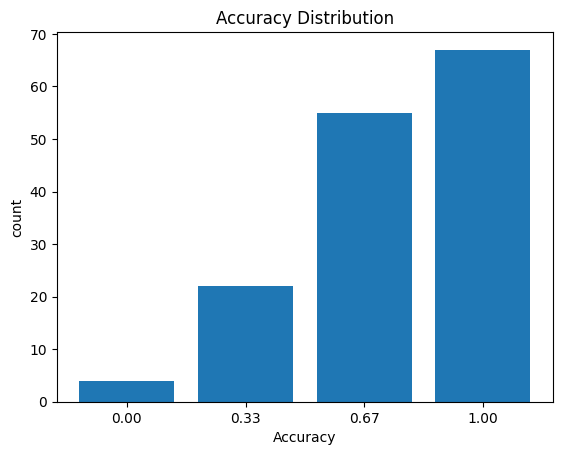

In [13]:
from collections import Counter
distribution = Counter(accuracy_data.values())
print(distribution)
import matplotlib.pyplot as plt
keys = sorted(distribution)
plt.bar([f'{k:.2f}' for k in keys], [distribution[k] for k in keys])
plt.xlabel('Accuracy')
plt.ylabel('count')
plt.title('Accuracy Distribution')
plt.show()

# complexity

In [14]:
with open('../4.NFRComplexity/data.json', 'r', encoding='utf-8') as file:
    data = json.load(file)

complexity_data = {}
for nfr in data:
    complexity_data[nfr['id']] = nfr['complexity']

Counter({1: 56, 0: 49, 2: 28, 3: 12, 4: 2, 23: 1})


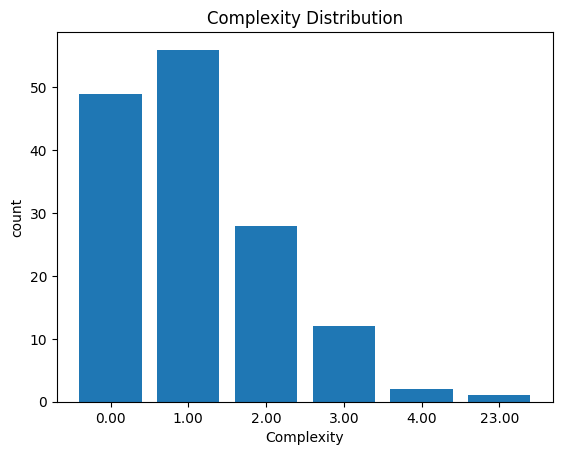

In [15]:
from collections import Counter
distribution = Counter(complexity_data.values())
print(distribution)
keys = sorted(distribution)
plt.bar([f'{k:.2f}' for k in keys], [distribution[k] for k in keys])
plt.xlabel('Complexity')
plt.ylabel('count')
plt.title('Complexity Distribution')
plt.show()

# tracability

In [16]:
with open('../6.NFRTracability/data-tracability.json', 'r', encoding='utf-8') as file:
    data = json.load(file)

locc_data = {}
cdc_data = {}
cdo_data = {}
docs_data = {}
docm_data = {}
for nfr in data:
    nfr_id = nfr['id']
    locc_data[nfr_id] = nfr['locc']
    cdc_data[nfr_id] = nfr['cdc']
    cdo_data[nfr_id] = nfr['cdo']
    docs_data[nfr_id] = nfr['docs']
    docm_data[nfr_id] = nfr['docm']

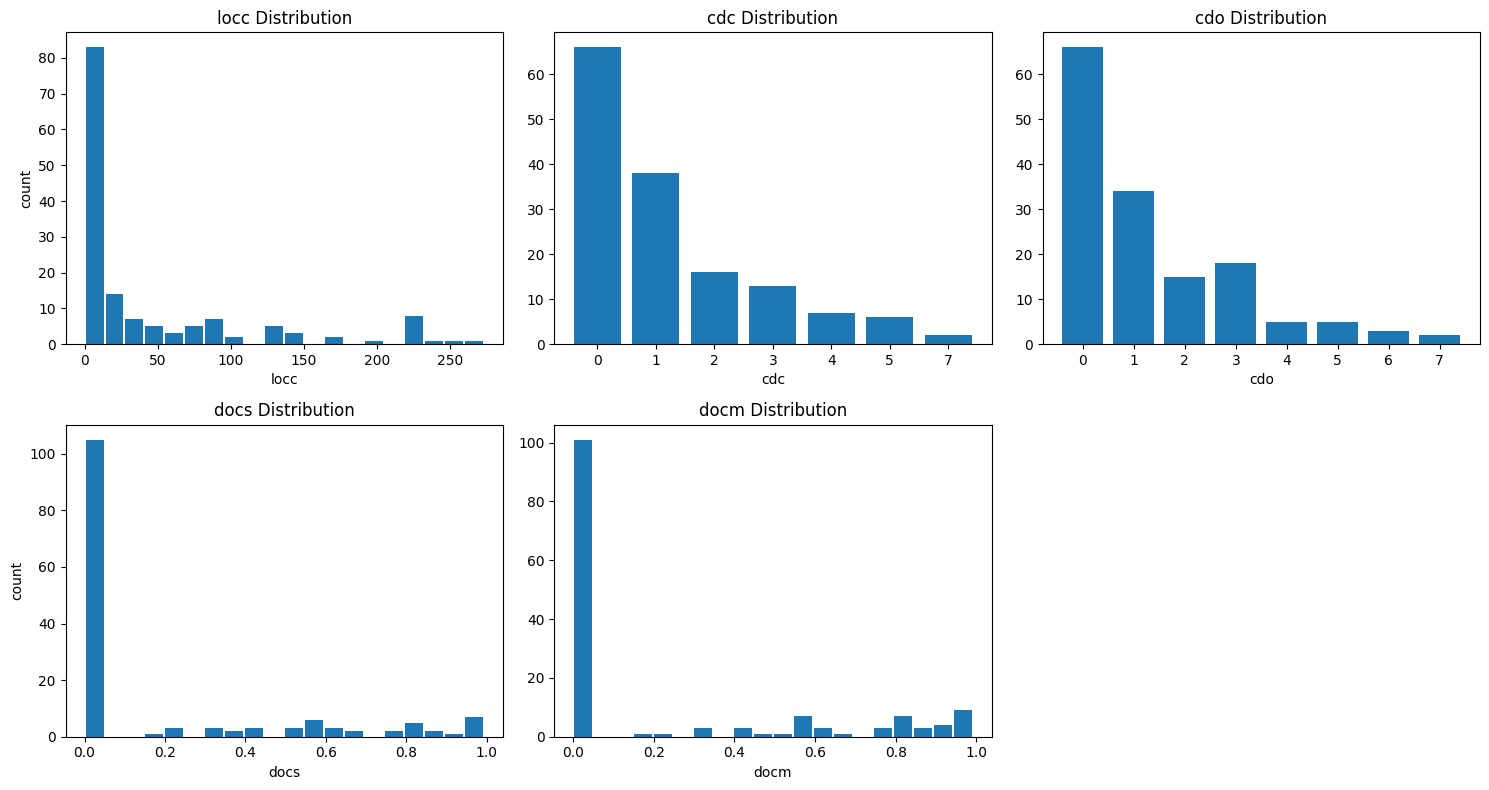

In [17]:
from collections import Counter
import matplotlib.pyplot as plt

tracabilities = [('locc', locc_data), ('cdc', cdc_data), ('cdo', cdo_data),
                 ('docs', docs_data), ('docm', docm_data)]

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()
for ax, (tracability, tracability_data) in zip(axes, tracabilities):
    vals = list(tracability_data.values())
    distribution = Counter(vals)
    if len(distribution) <= 15:                      # discrete -> categorical bars
        keys = sorted(distribution)
        ax.bar([f'{k:g}' for k in keys], [distribution[k] for k in keys])
    else:                                            # continuous -> binned histogram
        ax.hist(vals, bins=20, rwidth=0.9)
    ax.set_xlabel(tracability)
    ax.set_title(f'{tracability} Distribution')
axes[0].set_ylabel('count')
axes[3].set_ylabel('count')
axes[5].axis('off')
plt.tight_layout()
plt.show()

# ambiguity

In [18]:
with open('../14.ambiguity_again/second round/data_resolved.json', 'r', encoding='utf-8') as file:
    data = json.load(file)

lexical_data = {}
syntactic_data = {}
semantic_data = {}
vagueness_data = {}
incompleteness_data = {}
referential_data = {}
ambiguity_exists_data = {}
sum_ambiguity_data = {}
sum_ambiguity_only_incomplete_and_vague_data = {}
ambiguity_only_incomplete_and_vague_exists_data = {}
for nfr in data:
    nfr_id = nfr['id']
    lexical_data[nfr_id] = nfr['Lexical']
    syntactic_data[nfr_id] = nfr['Syntactic']
    semantic_data[nfr_id] = nfr['Semantic']
    vagueness_data[nfr_id] = nfr['Vagueness']
    incompleteness_data[nfr_id] = nfr['Incompleteness']
    referential_data[nfr_id] = nfr['Referential']
    ambiguity_flags = [
        nfr['Lexical'], nfr['Syntactic'], nfr['Semantic'],
        nfr['Vagueness'], nfr['Incompleteness'], nfr['Referential'],
    ]
    ambiguity_exists_data[nfr_id] = any(ambiguity_flags)
    sum_ambiguity_data[nfr_id] = sum(ambiguity_flags)
    sum_ambiguity_only_incomplete_and_vague_data[nfr_id] = ambiguity_flags[3] + ambiguity_flags[4]
    ambiguity_only_incomplete_and_vague_exists_data[nfr_id] = sum_ambiguity_only_incomplete_and_vague_data[nfr_id] > 0

# Relevancy

In [19]:
with open('../7.NFRRelevancy/prioritized.json', 'r', encoding='utf-8') as file:
    data = json.load(file)

value_pct_data = {}
cost_pct_data = {}
risk_pct_data = {}
priority_data = {}

for nfr in data:
    nfr_id = nfr['id']
    value_pct_data[nfr_id] = nfr['value_pct']
    cost_pct_data[nfr_id] = nfr['cost_pct']
    risk_pct_data[nfr_id] = nfr['risk_pct']
    priority_data[nfr_id] = nfr['priority']


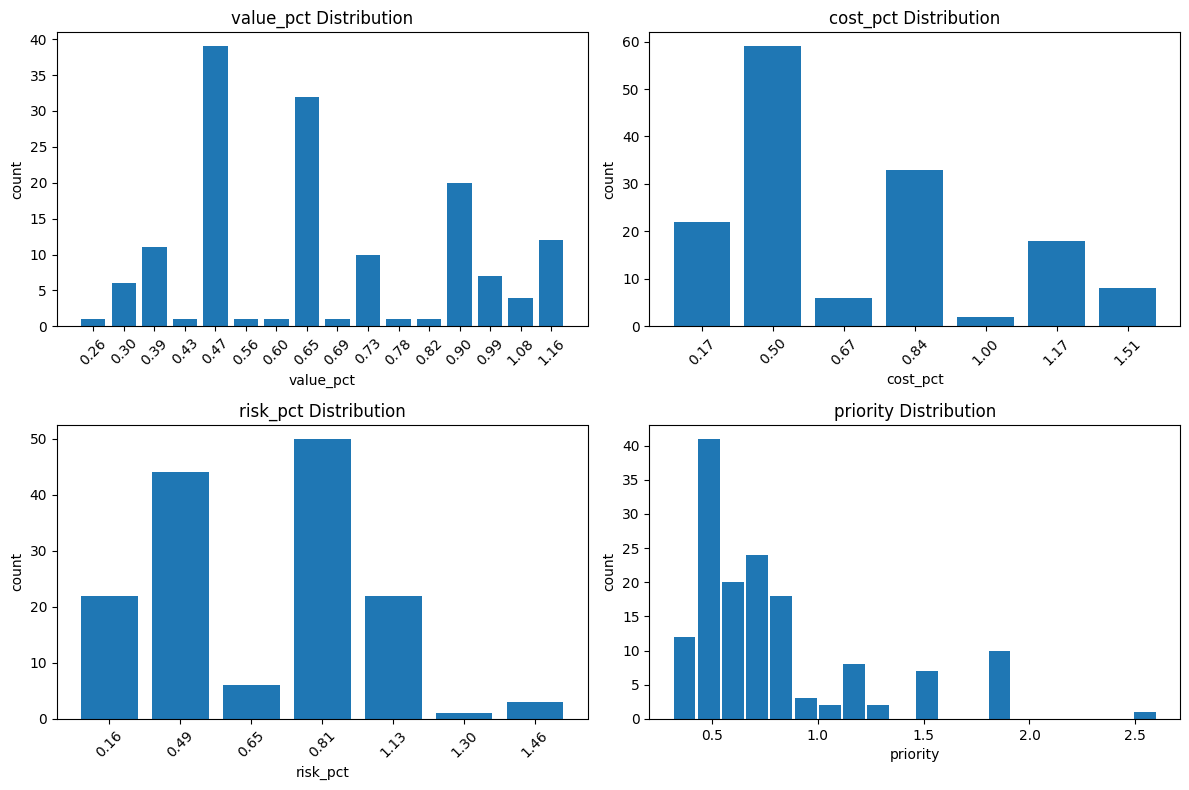

In [20]:
from collections import Counter

relevancy_metrics = [
    ('value_pct', value_pct_data),
    ('cost_pct', cost_pct_data),
    ('risk_pct', risk_pct_data),
    ('priority', priority_data),
]

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()
for ax, (name, data_dict) in zip(axes, relevancy_metrics):
    vals = list(data_dict.values())
    distribution = Counter(vals)
    if len(distribution) <= 20:
        keys = sorted(distribution)
        ax.bar([f'{k:.2f}' for k in keys], [distribution[k] for k in keys])
        ax.tick_params(axis='x', rotation=45)
    else:
        ax.hist(vals, bins=20, rwidth=0.9)
    ax.set_xlabel(name)
    ax.set_ylabel('count')
    ax.set_title(f'{name} Distribution')

plt.tight_layout()
plt.show()
